In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
df = pd.read_csv('../data/athlete_events.csv')
noc = pd.read_csv('../data/noc_regions.csv')

# Merge to get country names
df = pd.merge(df, noc, on='NOC', how='left')

# Create our 'Medal_Won' target variable (1 if they won any medal, 0 otherwise)
df['Medal_Won'] = df['Medal'].notna().astype(int)

# Check the baseline: What percentage of athletes actually win a medal?
print(f"Medal Rate: {df['Medal_Won'].mean():.2%}")

Medal Rate: 14.67%


Missing values per column:
ID                0
Name              0
Sex               0
Age            9474
Height        60171
Weight        62875
Team              0
NOC               0
Games             0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal        231333
region          370
notes        266077
Medal_Won         0
dtype: int64


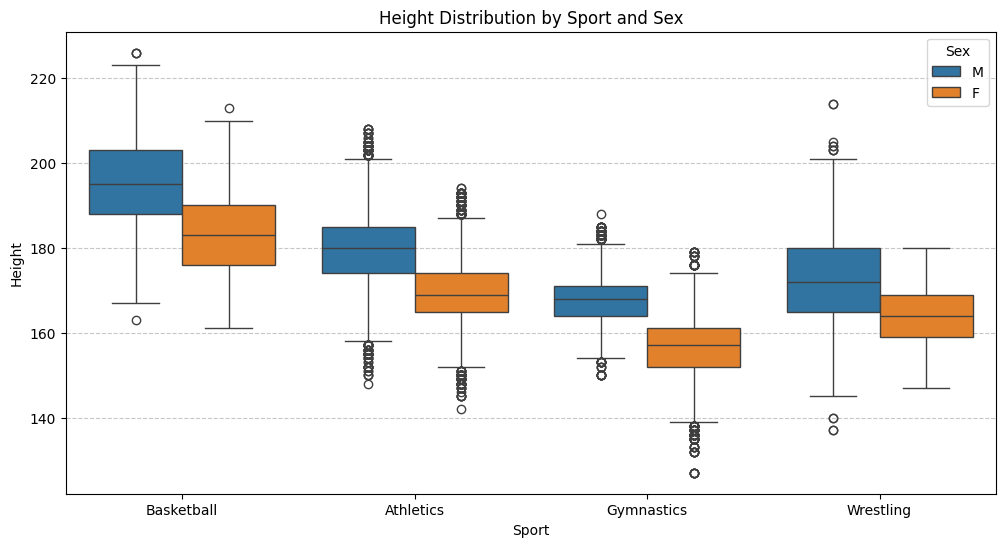

In [3]:
# 1. Check for missing values again now that we've merged
print("Missing values per column:")
print(df.isnull().sum())

# 2. Visualize why 'Sport' matters for Height and Weight
plt.figure(figsize=(12, 6))
# We'll look at 4 very different sports
sample_sports = ['Gymnastics', 'Basketball', 'Wrestling', 'Athletics']
sns.boxplot(data=df[df['Sport'].isin(sample_sports)], x='Sport', y='Height', hue='Sex')
plt.title('Height Distribution by Sport and Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
# Create a new column: 1 if they won a medal, 0 if they didn't
df['Medal_Won'] = df['Medal'].notna().astype(int)

# Verify the count
print(df['Medal_Won'].value_counts())

Medal_Won
0    231333
1     39783
Name: count, dtype: int64


In [5]:
# Fill missing Age using the median age of the specific Event
df['Age'] = df['Age'].fillna(df.groupby('Event')['Age'].transform('median'))

# Check if any Age values are still missing
print(f"Missing Age values: {df['Age'].isnull().sum()}")

Missing Age values: 142


In [6]:
# Fill any remaining Age gaps with the median of the entire dataset
df['Age'] = df['Age'].fillna(df['Age'].median())

# Final check
print(f"Final missing Age values: {df['Age'].isnull().sum()}")

Final missing Age values: 0


In [7]:
# Fill missing Height based on the median of their specific Sport and Sex
df['Height'] = df['Height'].fillna(df.groupby(['Sport', 'Sex'])['Height'].transform('median'))

# Check if any Height values are still missing
print(f"Missing Height values: {df['Height'].isnull().sum()}")

Missing Height values: 100


In [8]:
# Fill the remaining 100 Height gaps with the median of the entire dataset
df['Height'] = df['Height'].fillna(df['Height'].median())

# Final check
print(f"Final missing Height values: {df['Height'].isnull().sum()}")

Final missing Height values: 0


In [9]:
# Fill missing Weight based on the median of their specific Sport and Sex
df['Weight'] = df['Weight'].fillna(df.groupby(['Sport', 'Sex'])['Weight'].transform('median'))

# Check if any Weight values are still missing
print(f"Missing Weight values: {df['Weight'].isnull().sum()}")

Missing Weight values: 595


In [10]:
# Fill the remaining 595 Weight gaps with the median of the entire dataset
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

# Final check
print(f"Final missing Weight values: {df['Weight'].isnull().sum()}")

Final missing Weight values: 0


In [11]:
# Fill the few missing region names with 'Unknown'
df['region'] = df['region'].fillna('Unknown')

# Run one final check across the whole dataframe
print("Final check for any missing values:")
print(df.isnull().sum())

Final check for any missing values:
ID                0
Name              0
Sex               0
Age               0
Height            0
Weight            0
Team              0
NOC               0
Games             0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal        231333
region            0
notes        266077
Medal_Won         0
dtype: int64


In [12]:
# Save the cleaned dataframe to a new CSV file
df.to_csv('../data/athlete_events_cleaned.csv', index=False)

print("File saved successfully as athlete_events_cleaned.csv")

File saved successfully as athlete_events_cleaned.csv


In [13]:
# List of columns that won't help the ML model predict a medal
columns_to_drop = ['ID', 'Name', 'Games', 'Event', 'Medal', 'notes']

# Drop them from our dataframe
df_ml = df.drop(columns=columns_to_drop)

# Look at our new, leaner dataset
print("Columns remaining for Machine Learning:")
print(df_ml.columns.tolist())
print(f"\nNew shape: {df_ml.shape}")

Columns remaining for Machine Learning:
['Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'region', 'Medal_Won']

New shape: (271116, 12)


In [14]:
# Convert Sex to binary: 1 for Male, 0 for Female
df_ml['Sex'] = df_ml['Sex'].map({'M': 1, 'F': 0})

# Convert Season to binary: 1 for Summer, 0 for Winter
df_ml['Season'] = df_ml['Season'].map({'Summer': 1, 'Winter': 0})

# Check the first few rows to see the transformation
print(df_ml[['Sex', 'Season']].head())

   Sex  Season
0    1       1
1    1       1
2    1       1
3    1       1
4    0       0


In [15]:
# Create a list of columns to frequency encode
categorical_cols = ['Team', 'NOC', 'City', 'Sport', 'region']

for col in categorical_cols:
    # Get the frequency of each category
    freq = df_ml[col].value_counts(normalize=True)
    # Map those frequencies back to the dataframe
    df_ml[col] = df_ml[col].map(freq)

# Show the first few rows of the transformed columns
print(df_ml[categorical_cols].head())

       Team       NOC      City     Sport    region
0  0.018350  0.018962  0.047865  0.016731  0.021489
1  0.018350  0.018962  0.082717  0.014020  0.021489
2  0.012629  0.013168  0.015831  0.024879  0.013168
3  0.000022  0.013168  0.026443  0.000627  0.013168
4  0.021091  0.021537  0.009734  0.020703  0.021537


In [16]:
# Check the data types of our new ML dataframe
print(df_ml.dtypes)

# Confirm there are no missing values created during encoding
print(f"\nMissing values: {df_ml.isnull().sum().sum()}")

Sex            int64
Age          float64
Height       float64
Weight       float64
Team         float64
NOC          float64
Year           int64
Season         int64
City         float64
Sport        float64
region       float64
Medal_Won      int64
dtype: object

Missing values: 0


In [17]:
# The target variable we want to predict
y = df_ml['Medal_Won']

# The features we will use to predict it (everything except the target)
X = df_ml.drop(columns=['Medal_Won'])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (271116, 11)
Target shape: (271116,)


In [18]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 216892
Testing set size: 54224


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
# n_estimators=100 means we are using 100 "trees" in our forest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on your training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [20]:
from sklearn.metrics import accuracy_score, classification_report

# Use the model to predict medals for the test set
y_pred = model.predict(X_test)

# Calculate the overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 89.01%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     46267
           1       0.67      0.49      0.57      7957

    accuracy                           0.89     54224
   macro avg       0.79      0.72      0.75     54224
weighted avg       0.88      0.89      0.88     54224



In [21]:
# Configuration #2: Random Forest with Balanced Class Weights
model_balanced = RandomForestClassifier(n_estimators=100, 
                                        class_weight='balanced', 
                                        random_state=42, 
                                        n_jobs=-1)

# Train the new version
model_balanced.fit(X_train, y_train)

# Predict and evaluate
y_pred_balanced = model_balanced.predict(X_test)

print(f"Balanced Model Accuracy: {accuracy_score(y_test, y_pred_balanced):.2%}")
print("\nBalanced Classification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Accuracy: 87.86%

Balanced Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     46267
           1       0.60      0.53      0.56      7957

    accuracy                           0.88     54224
   macro avg       0.76      0.74      0.75     54224
weighted avg       0.87      0.88      0.88     54224



In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Configuration #3: Gradient Boosting
# This model builds trees sequentially to minimize errors
model_gb = HistGradientBoostingClassifier(random_state=42)

# Train the model
model_gb.fit(X_train, y_train)

# Predict and evaluate
y_pred_gb = model_gb.predict(X_test)

print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.2%}")
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 87.36%

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     46267
           1       0.82      0.18      0.29      7957

    accuracy                           0.87     54224
   macro avg       0.85      0.59      0.61     54224
weighted avg       0.87      0.87      0.84     54224



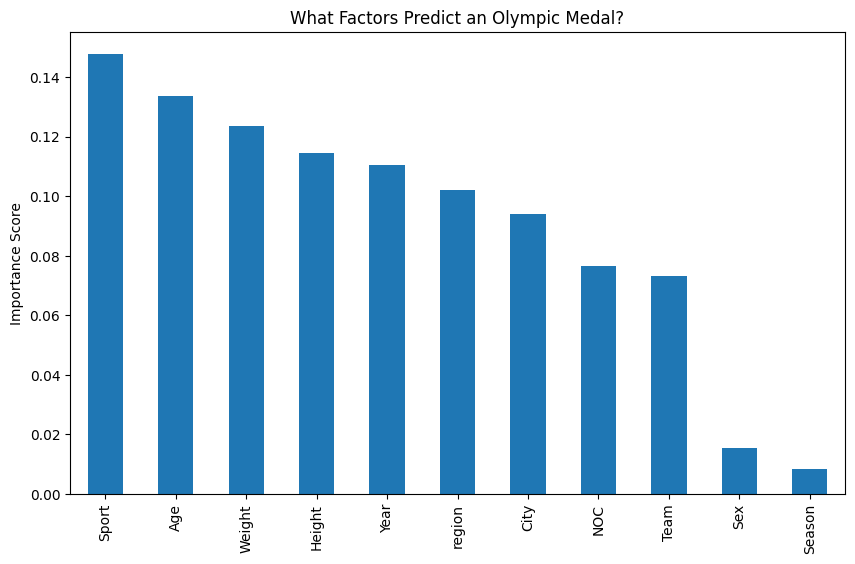

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from your best model (the balanced one)
importances = pd.Series(model_balanced.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title("What Factors Predict an Olympic Medal?")
plt.ylabel("Importance Score")
plt.show()